In [2]:
#TASK 1: DATA EXPLORATION (30 min)
#- Load data, check shape, types
#- Identify missing values & duplicates
#- Generate data quality report
import pandas as pd
import numpy as np
df= pd.read_csv('Retail_Sales.csv')
data_shape = df.shape
print(f"Shape of the CSV file: {data_shape}")
print(f"Number of rows: {data_shape[0]}")
print(f"Number of columns: {data_shape[1]}")
print()
print(df.dtypes)
print()
print(df.isnull().values.any())
print(df.isnull().sum())
print()
print(df.duplicated().any())
print(df.duplicated().sum())


Shape of the CSV file: (1020, 12)
Number of rows: 1020
Number of columns: 12

Transaction_ID       object
Date                 object
Store_ID             object
City                 object
Product_Category     object
Product_Name         object
Quantity              int64
Unit_Price           object
Customer_Age        float64
Customer_Gender      object
Payment_Method       object
Discount_Applied     object
dtype: object

True
Transaction_ID       21
Date                  0
Store_ID              0
City                161
Product_Category      0
Product_Name        176
Quantity              0
Unit_Price            0
Customer_Age        166
Customer_Gender     228
Payment_Method        0
Discount_Applied    161
dtype: int64

True
20


C:\Users\PIJUSH PANDIT\AppData\Local\Temp\ipykernel_11180\340676774.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"], errors="coerce")


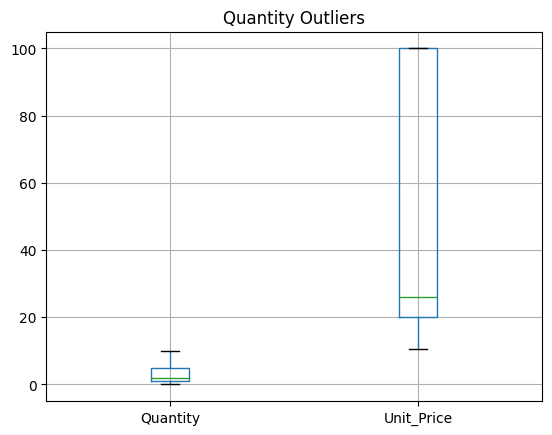

In [3]:
#TASK 2: DATA CLEANING (60 min)
#- Handle missing values
#- Remove duplicates
#- Fix data types & standardize text
#- Handle outliers
#- Create new features (Month, Age_Group, Price_Category)
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
df= pd.read_csv('Retail_Sales.csv')
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df.drop_duplicates(inplace=True)
df['Transaction_ID'] = df['Transaction_ID'].astype(str)
wordtonumber = {'OneZeroFive' : 105,
               'Twenty' : 20,
               'Ten' : 10}
gender = {'F' : 'Female',
          'M' : 'Male'}
df['Store_ID'] = df['Store_ID'].replace(wordtonumber)
df['Store_ID'] = df['Store_ID'].astype(int)
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df['City'] = df['City'].astype(str)
df['Product_Category'] = df['Product_Category'].astype(str)
df['Product_Name']=df['Product_Name'].astype(str)
df.replace(wordtonumber, inplace=True)
num_cols = ["Quantity","Unit_Price","Customer_Age","Discount_Applied"]
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors = "coerce")

df.loc[df['Quantity']<0,'Quantity']=0
df['Quantity'] = df['Quantity'].clip(upper=10)
df['Customer_Age'] = df['Customer_Age'].clip(upper=100)
df['Unit_Price'] = df['Unit_Price'].replace(wordtonumber)
df['Unit_Price'] = df['Unit_Price'].clip(upper=100)
df['Customer_Gender'] = df['Customer_Gender'].replace(gender)
df['Customer_Gender'] = df['Customer_Gender'].astype(str)
df['Payment_Method'] = df['Payment_Method'].astype(str)
df['Discount_Applied'] = df['Discount_Applied'].replace(wordtonumber)
df['City'] = df['City'].str.strip()
df['City'] = df['City'].str.title()
df['Payment_Method'] = df['Payment_Method'].str.strip()
df['Payment_Method'] = df['Payment_Method'].str.title()
df["City"] = df["City"].replace("Nan", pd.NA)
df["Product_Name"] = df["Product_Name"].replace("nan", pd.NA)
df["Customer_Gender"] = df["Customer_Gender"].replace("nan", pd.NA)
df.dropna(inplace=True)
plt.title("Quantity Outliers")
df.boxplot(column =['Quantity', 'Unit_Price'])
plt.show()
df.to_csv("Semi_Clean_Retail_Sale.csv",index=False)

In [4]:
df1 = pd.read_csv('Semi_Clean_Retail_Sale.csv')
df1["Date"] = pd.to_datetime(df1["Date"], errors="coerce")
df1['Month'] = df1['Date'].dt.month_name()
df1['Year'] = df1['Date'].dt.year
df1['Day'] = df1['Date'].dt.day
bins=[0,19,40,60,80,120]
labels = ['Teeneger', 'Young Adult', 'Adult', 'Senior', 'Super Senior']
df1['Age_Group'] = pd.cut(df1['Customer_Age'], bins=bins, labels=labels)
bins=[0,20,50,100]
labels = ['Low', 'Medium', 'High']
df1['Price_Category'] = pd.cut(df1['Unit_Price'], bins=bins, labels=labels)
df1['Quantity'] = df1['Quantity'].replace(0,1)
df1['Revenue'] = df1['Quantity'] * df1['Unit_Price']
Q1 = df[['Quantity', 'Unit_Price']].quantile(.25)
Q3 = df[['Quantity', 'Unit_Price']].quantile(.75)
IQR = Q3 - Q1
Lower = Q1 - 1.5*IQR
Upper = Q3 + 1.5*IQR
df1 = df1[
    ~((df1[["Quantity","Unit_Price"]] < Lower) |
      (df1[["Quantity","Unit_Price"]] > Upper)).any(axis=1)
]
df1.to_csv('Retail_Sale_Clean.csv', index = False)

,Quantity,Unit_Price,Customer_Age,Discount_Applied
count,373.000000,373.000000,373.000000,373.000000
mean,3.450402,51.673646,49.833780,15.388740
std,3.129951,40.211027,28.001713,18.196112
min,1.000000,10.500000,18.000000,0.000000
25%,1.000000,20.000000,25.000000,5.000000
50%,2.000000,25.990000,45.000000,10.000000
75%,5.000000,100.000000,60.000000,10.000000
max,10.000000,100.000000,100.000000,50.000000


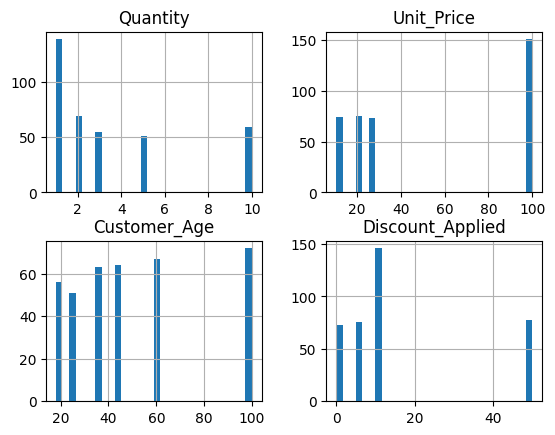

In [5]:
#TASK 3: VISUALIZATION & EDA (90 min)
#- Univariate: distributions, counts
#- Bivariate: category analysis
#- Time series: trends
#- Correlation heatmap
import matplotlib.pyplot as plt
c = ["Quantity","Unit_Price","Customer_Age","Discount_Applied"]
df1[c].hist(bins=30)
plt.show
df1[c].describe()

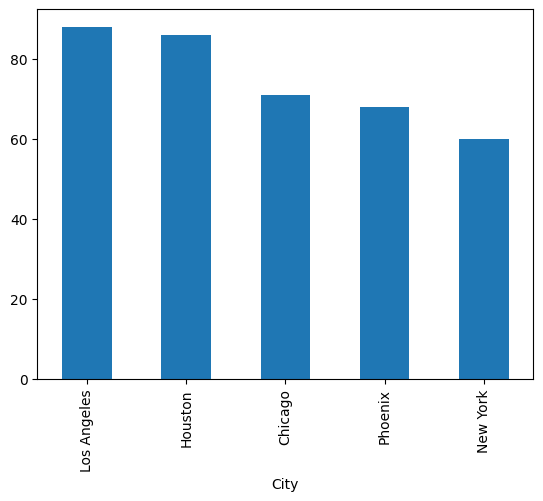

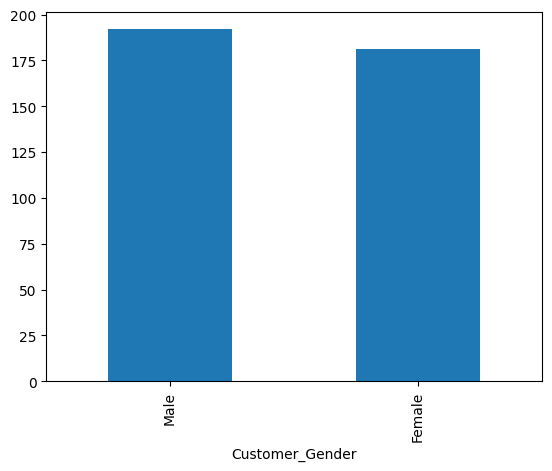

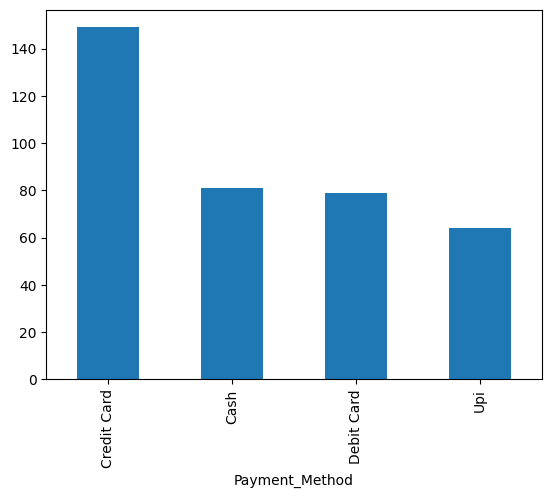

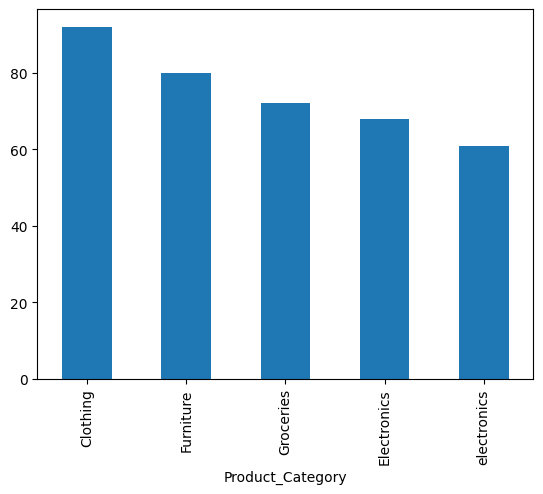

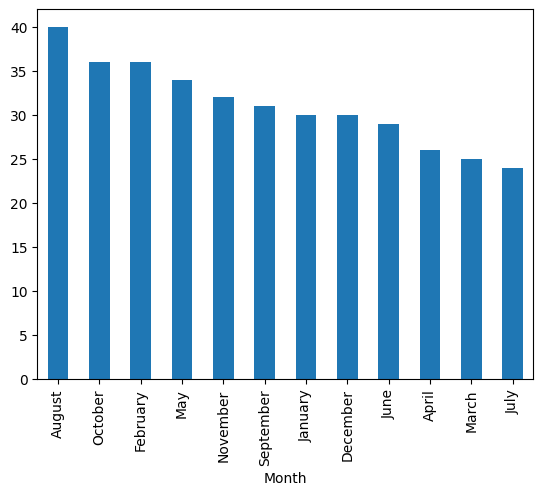

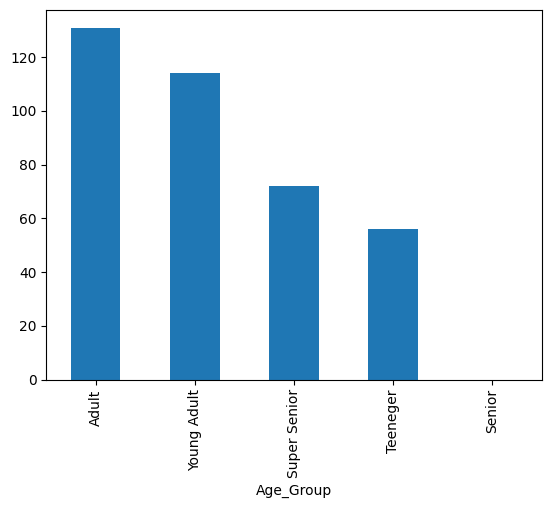

In [42]:
cols = ["City","Customer_Gender","Payment_Method",
        "Product_Category","Month","Age_Group"]
for i in cols:
    df1[i].value_counts().plot(kind='bar')
    plt.show()

<Axes: xlabel='Discount_Applied'>

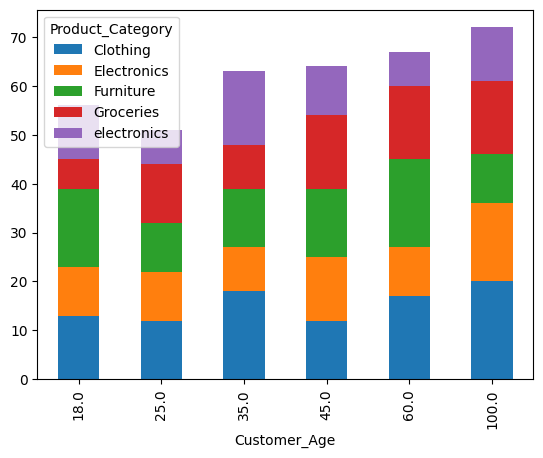

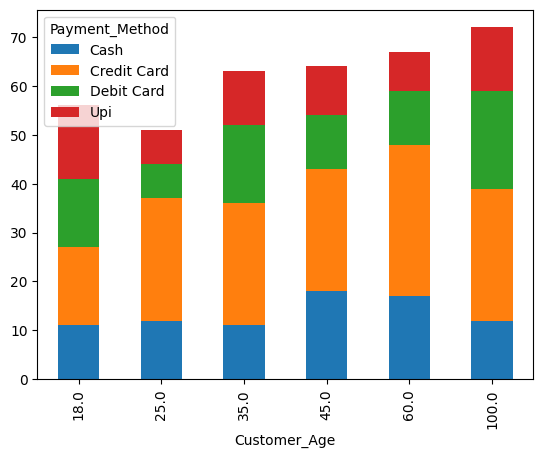

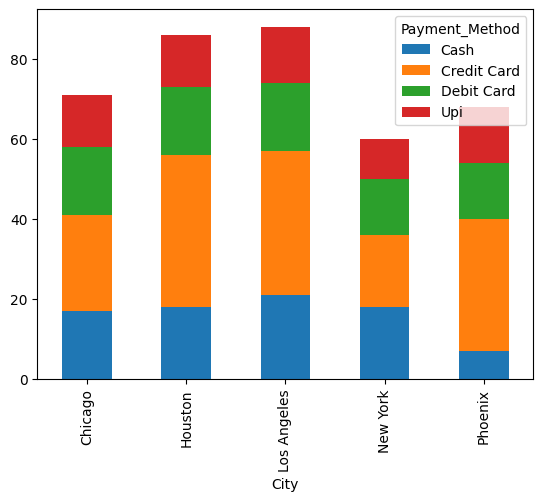

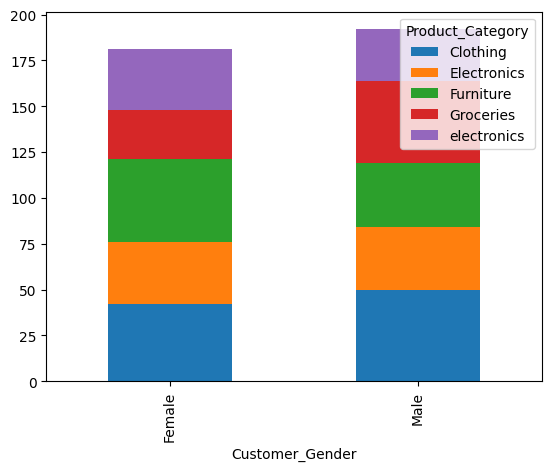

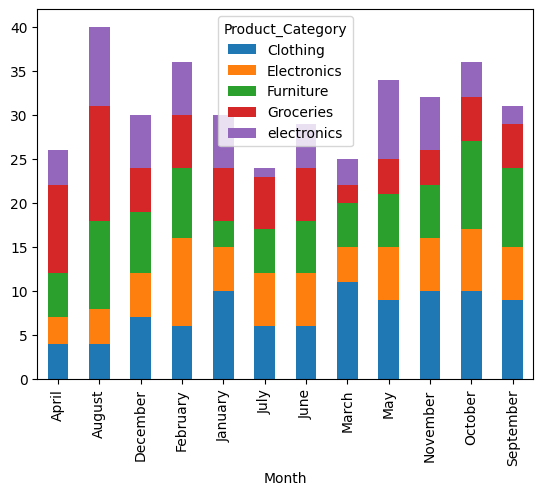

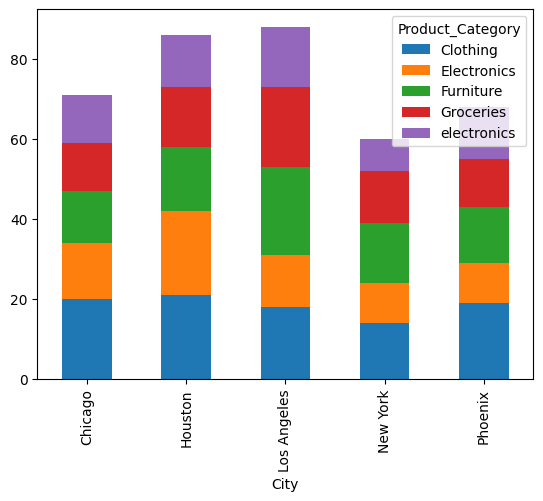

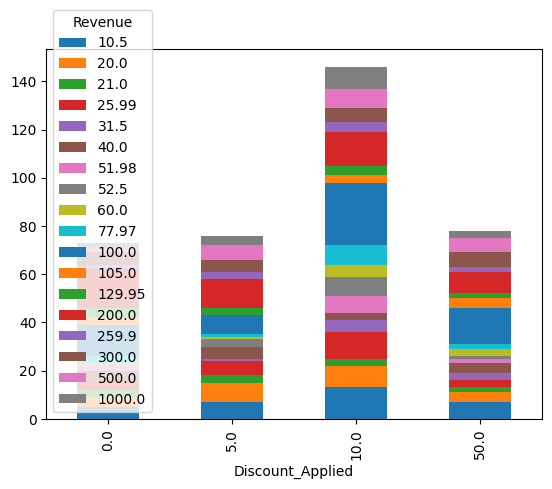

In [6]:
import pandas as pd
pd.crosstab(df1['Customer_Age'],df1['Product_Category']).plot(kind='bar', stacked = True)
pd.crosstab(df1['Customer_Age'],df1['Payment_Method']).plot(kind='bar', stacked = True)
pd.crosstab(df1['City'],df1['Payment_Method']).plot(kind='bar', stacked = True)
pd.crosstab(df1['Customer_Gender'],df1['Product_Category']).plot(kind='bar', stacked = True)
pd.crosstab(df1['Month'],df1['Product_Category']).plot(kind='bar', stacked = True)
pd.crosstab(df1['City'],df1['Product_Category']).plot(kind='bar', stacked = True)
pd.crosstab(df1['Discount_Applied'],df1['Revenue']).plot(kind='bar', stacked = True)

<Axes: xlabel='Month'>

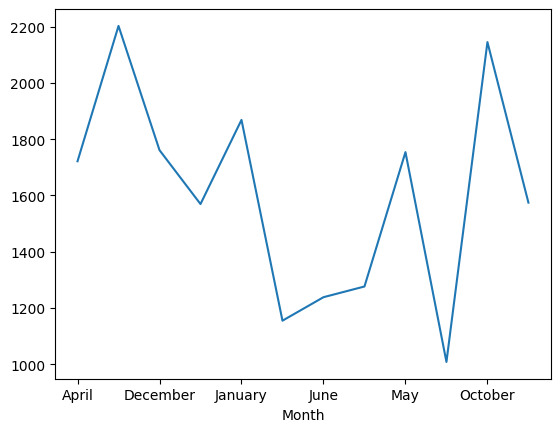

In [6]:
Monthly_Sale = df1.groupby('Month')['Unit_Price'].sum() #monthly sale trend
Monthly_Sale.plot(kind = 'line')


<Axes: xlabel='Day'>

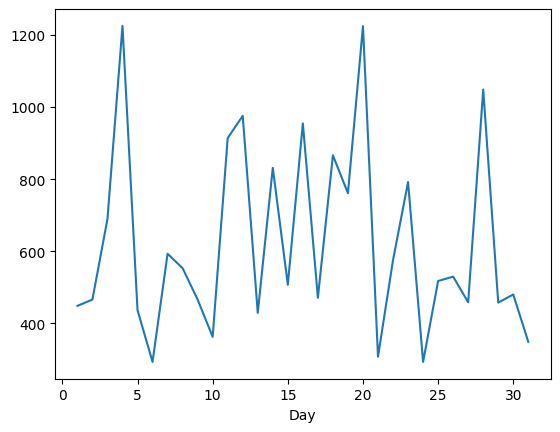

In [24]:
Daily_Sale = df1.groupby('Day')['Unit_Price'].sum() #daily sale trend
Daily_Sale.plot(kind = 'line')

In [22]:
#TASK 4: STATISTICAL ANALYSIS 
#- Descriptive statistics
#- Group-wise analysis
#- Business metrics
print(df1.groupby('City')['Unit_Price'].sum())
print()
print(df1.groupby('City')['Unit_Price'].agg(['mean','median','max','min','count']))
print()
print(df1.groupby(['City','Product_Category'])['Unit_Price'].sum())
print()
print(df1.groupby(["City","Product_Category"]).size())

City
Chicago        3922.39
Houston        4688.35
Los Angeles    4511.35
New York       3334.40
Phoenix        2817.78
Name: Unit_Price, dtype: float64

                  mean  median    max   min  count
City                                              
Chicago      55.244930   25.99  100.0  10.5     71
Houston      54.515698   25.99  100.0  10.5     86
Los Angeles  51.265341   25.99  100.0  10.5     88
New York     55.573333   25.99  100.0  10.5     60
Phoenix      41.437941   25.99  100.0  10.5     68

City         Product_Category
Chicago      Clothing            1263.48
             Electronics          749.47
             Furniture            816.49
             Groceries            531.50
             electronics          561.45
Houston      Clothing            1193.98
             Electronics          712.95
             Furniture            989.95
             Groceries            997.49
             electronics          793.98
Los Angeles  Clothing            1034.98
       

In [37]:
Total_Revenue = df1['Revenue'].sum() 
print(Total_Revenue)
print()
Total_Orders = df1['Transaction_ID'].nunique()
Avg_Order_Value = Total_Revenue / Total_Orders
print(Avg_Order_Value)
print()
Best_Category = df1.groupby('Product_Category')['Revenue'].sum().sort_values(ascending=False)
print(Best_Category)
print()
Top_City = df1.groupby('City')['Revenue'].sum().sort_values(ascending=False)
print(Top_City)
print()
Avg_Customer_Age = df1['Customer_Age'].mean()
print(Avg_Customer_Age)

63105.87

171.95059945504087

Product_Category
Clothing       17780.38
Furniture      14833.36
Groceries      13151.61
electronics     8752.43
Electronics     8588.09
Name: Revenue, dtype: float64

City
Houston        15414.96
Los Angeles    13131.64
New York       12933.04
Chicago        12414.44
Phoenix         9211.79
Name: Revenue, dtype: float64

49.833780160857906


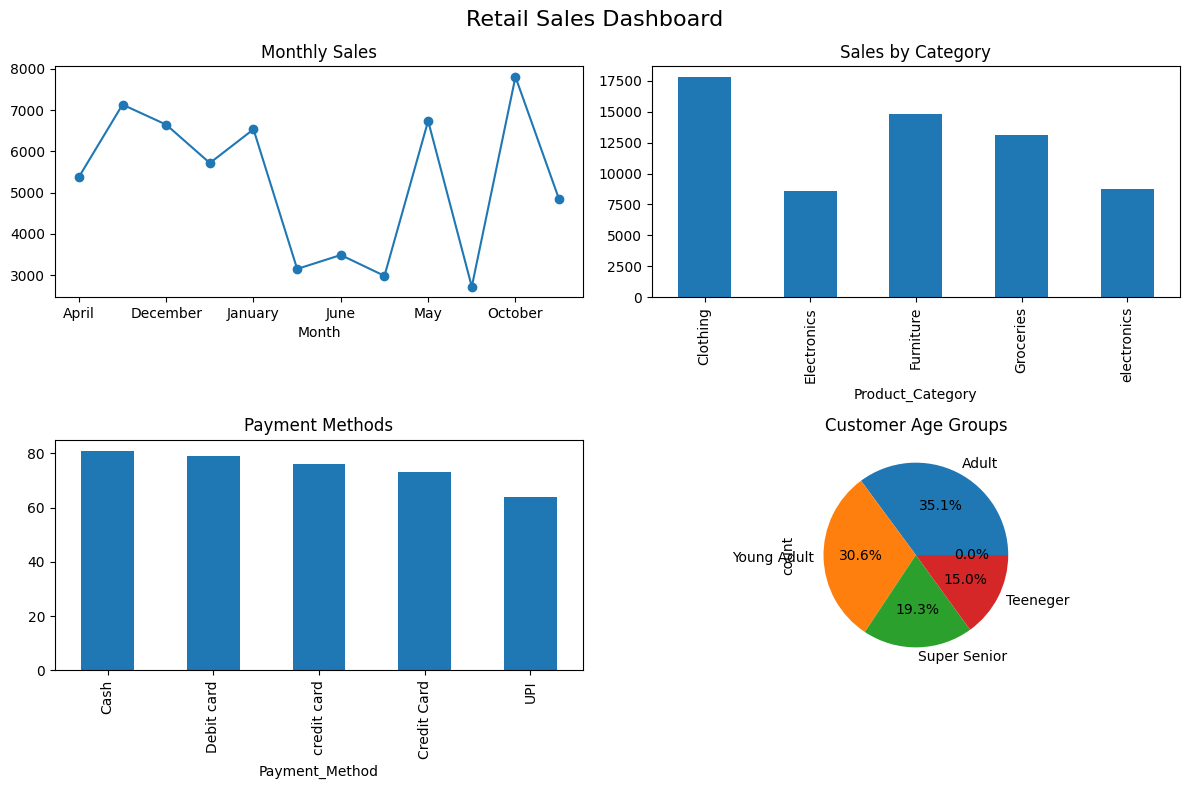

In [39]:
import matplotlib.pyplot as plt

monthly = df1.groupby("Month")["Revenue"].sum()
category = df1.groupby("Product_Category")["Revenue"].sum()
payment = df1["Payment_Method"].value_counts()
age = df1["Age_Group"].value_counts()

fig, axes = plt.subplots(2,2, figsize=(12,8))
fig.suptitle("Retail Sales Dashboard", fontsize=16)

monthly.plot(ax=axes[0,0], marker="o", title="Monthly Sales")
category.plot(kind="bar", ax=axes[0,1], title="Sales by Category")
payment.plot(kind="bar", ax=axes[1,0], title="Payment Methods")
age.plot(kind="pie", ax=axes[1,1], title="Customer Age Groups", autopct="%1.1f%%")

plt.tight_layout()
plt.show()


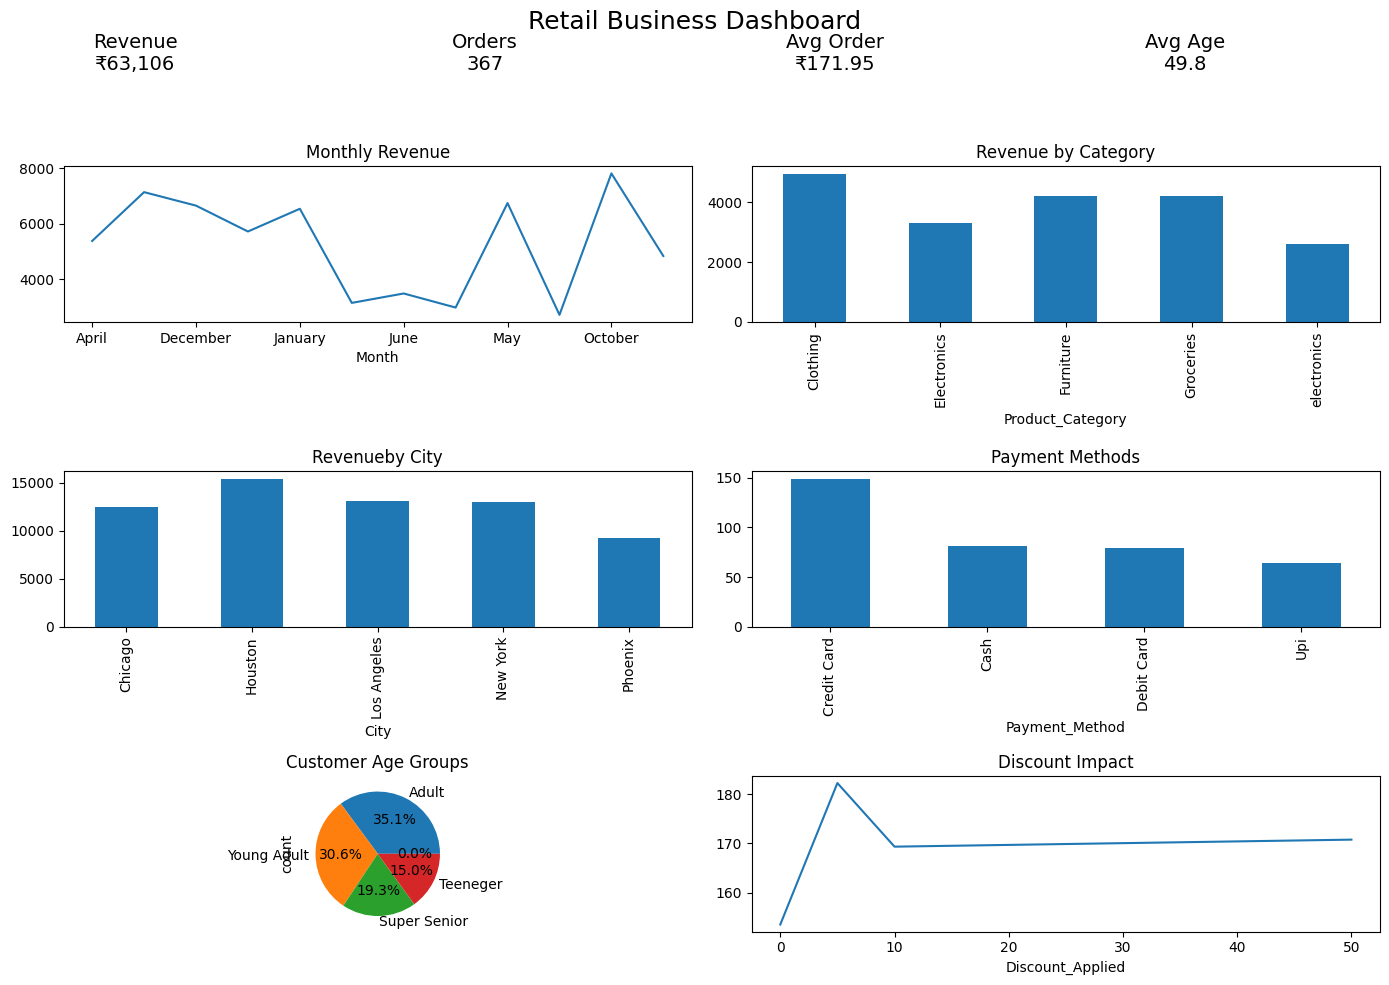

In [50]:
import matplotlib.pyplot as plt
Total_Revenue = df1['Revenue'].sum() 
Total_Orders = df1['Transaction_ID'].nunique()
Avg_Order_Value = Total_Revenue / Total_Orders
Avg_Customer_Age = df1['Customer_Age'].mean()

fig = plt.figure(figsize=(14,10))
fig.suptitle("Retail Business Dashboard", fontsize=18)
fig.text(0.1,0.92,f"Revenue\n₹{Total_Revenue:,.0f}",fontsize=14,ha="center")
fig.text(0.35,0.92,f"Orders\n{Total_Orders}",fontsize=14,ha="center")
fig.text(0.6,0.92,f"Avg Order\n₹{Avg_Order_Value:.2f}",fontsize=14,ha="center")
fig.text(0.85,0.92,f"Avg Age\n{Avg_Customer_Age:.1f}",fontsize=14,ha="center")

ax1 = plt.subplot(3,2,1)
df1.groupby("Month")["Revenue"].sum().plot(ax=ax1)
ax1.set_title("Monthly Revenue")

ax2 = plt.subplot(3,2,2)
df1.groupby("Product_Category")["Unit_Price"].sum().plot(kind="bar", ax=ax2)
ax2.set_title("Revenue by Category")

ax3 = plt.subplot(3,2,3)
df1.groupby("City")["Revenue"].sum().plot(kind="bar", ax=ax3)
ax3.set_title("Revenueby City")

ax4 = plt.subplot(3,2,4)
df1["Payment_Method"].value_counts().plot(kind="bar", ax=ax4)
ax4.set_title("Payment Methods")

ax5 = plt.subplot(3,2,5)
df1["Age_Group"].value_counts().plot(kind="pie", autopct="%1.1f%%", ax=ax5)
ax5.set_title("Customer Age Groups")

ax6 = plt.subplot(3,2,6)
df1.groupby("Discount_Applied")["Revenue"].mean().plot(ax=ax6)
ax6.set_title("Discount Impact")

plt.tight_layout(rect=[0,0,1,0.9])
plt.show()


INSIGHTS:
1. The variance of revenue of over months is noticeable.
2. After every month with high revenue revenue level falls down due to unavailability of stock.
3. Some product categories give maximum part of revenue.
4. Customers use one payment method, showing a clear preference for that option.
5. Reveneu increases to a certain percentage of discount then it decreases.

RCOMENDATIONS:
1. Increase marketing and stock level then revenue is on peak.
2. Focus the categories who are generate low revenue to boost revenue.
3. Increase adverticement to boost revenue in high performing cities.
4. Focus on logistics and supply chain of the cities with low revenue.
5. Increase latest and trendy fashion stock to attract new generation boost revenue from them.
6. Should apply moderate discount without increase profit margin.